In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests
from pysus import sim


In [2]:
def calcular_taxa_100k(obitos, populacao):
    return ((obitos / populacao) * 100000).round(2)

In [3]:
codigos_x = [f"X{i}" for i in range(85, 100)]
codigo_y = [f"Y0{i}" for i in range(0, 10)]
codigo_agressao = codigos_x + codigo_y


In [4]:
estados = ["AC", "AL", "AM", "AP", "BA", "CE", "DF", "ES", "GO", 
        "MA", "MG", "MS", "MT", "PA", "PB", "PE", "PI", "PR", 
        "RJ", "RN", "RO", "RR", "RS", "SC", "SE", "SP", "TO"]

anos = list(range(2015, 2022))

if os.path.exists("violencia_feminina.parquet"):    
    violencia_feminina = pd.read_parquet("violencia_feminina.parquet")
    print("Dados carregados do arquivo parquet.")
else:
    dfs = []
    
    for estado in estados:
        for ano in anos:
            df_temp = sim(state=estado, year=ano)
            df_filtrado = df_temp[
                (df_temp["SEXO"] == "2") &
                (df_temp["CAUSABAS"].str[:3].isin(codigo_agressao))
            ]
            dfs.append(df_filtrado)
            del df_temp
                
    violencia_feminina = pd.concat(dfs, ignore_index=True)
    violencia_feminina.to_parquet("violencia_feminina.parquet")

violencia_feminina["ANO"] = pd.to_datetime(
violencia_feminina["DTOBITO"], format="%d%m%Y", errors="coerce"
    ).dt.year
violencia_feminina = violencia_feminina.dropna(subset=["ANO"])
violencia_feminina["ANO"] = violencia_feminina["ANO"].astype(int)


print(f"Total de registros: {violencia_feminina.shape[0]}")
print(f"total de colunas: {violencia_feminina.shape[1]}")


Dados carregados do arquivo parquet.
Total de registros: 27264
total de colunas: 89


In [5]:
violencia_feminina["ESTADO"] = violencia_feminina["CODMUNOCOR"].str.strip().str[:2]

codigo_estado = {
    "11": "RO", "12": "AC", "13": "AM", "14": "RR", "15": "PA",
    "16": "AP", "17": "TO", "21": "MA", "22": "PI", "23": "CE",
    "24": "RN", "25": "PB", "26": "PE", "27": "AL", "28": "SE",
    "29": "BA", "31": "MG", "32": "ES", "33": "RJ", "35": "SP",
    "41": "PR", "42": "SC", "43": "RS", "50": "MS", "51": "MT",
    "52": "GO", "53": "DF"
}

violencia_feminina["ESTADO"] = violencia_feminina["ESTADO"].map(codigo_estado)


In [6]:
url = "https://servicodados.ibge.gov.br/api/v3/agregados/6579/periodos/2015|2016|2017|2018|2019|2020|2021|2022/variaveis/9324?localidades=N3[all]"

response = requests.get(url)
dados = response.json()
print(response.status_code)

200


In [7]:
registros = []

for serie in dados[0]["resultados"][0]["series"]:
    estado = codigo_estado[serie["localidade"]["id"]]
    for ano, populacao in serie["serie"].items():
        registros.append({
            "ESTADO": estado,
            "ANO": int(ano),
            "POPULACAO": int(populacao)
        })
        

populacao_df = pd.DataFrame(registros)
print(populacao_df.head(5))
print(populacao_df.shape)


  ESTADO   ANO  POPULACAO
0     RO  2015    1768204
1     RO  2016    1787279
2     RO  2017    1805788
3     RO  2018    1757589
4     RO  2019    1777225
(189, 3)


In [8]:
url = "https://servicodados.ibge.gov.br/api/v3/agregados/6579/periodos/2015|2016|2017|2018|2019|2020|2021|2022/variaveis/9324?localidades=N3[all]"

response = requests.get(url)
dados = response.json()


In [9]:
obitos_agrupados = violencia_feminina.groupby(["ESTADO", "ANO"]).size().reset_index(name="OBITOS")

In [10]:
# 1. Criamos um DataFrame de 1 linha com o dado oficial auditado no Tabnet
dado_rj_2021 = pd.DataFrame(
    [{"ESTADO": "RJ", "ANO": 2021, "OBITOS": 281}]
)

# 2. Anexamos essa linha à nossa tabela agrupada
obitos_agrupados = pd.concat(
    [obitos_agrupados, dado_rj_2021], ignore_index=True
)

# 3. Ordenamos para manter a organização limpa e checamos se o RJ-2021 apareceu!
obitos_agrupados = obitos_agrupados.sort_values(
    ["ESTADO", "ANO"]
).reset_index(drop=True)

print("--- CHECAGEM DO RIO DE JANEIRO EM 2021 ---")
print(
    obitos_agrupados[
        (obitos_agrupados["ESTADO"] == "RJ") & (obitos_agrupados["ANO"] == 2021)
    ]
)

--- CHECAGEM DO RIO DE JANEIRO EM 2021 ---
    ESTADO   ANO  OBITOS
132     RJ  2021     281


In [11]:
tabela_unificada = pd.merge(obitos_agrupados, populacao_df, on=["ESTADO", "ANO"], how="inner")

In [12]:
tabela_unificada["TAXA_POR_100K"] = calcular_taxa_100k(
    tabela_unificada["OBITOS"],
    tabela_unificada["POPULACAO"]
).round(2)

In [13]:
print(tabela_unificada)

    ESTADO   ANO  OBITOS  POPULACAO  TAXA_POR_100K
0       AC  2015      19     803513           2.36
1       AC  2016      23     816687           2.82
2       AC  2017      34     829619           4.10
3       AC  2018      35     869265           4.03
4       AC  2019      32     881935           3.63
..     ...   ...     ...        ...            ...
184     TO  2017      37    1550194           2.39
185     TO  2018      46    1555229           2.96
186     TO  2019      32    1572866           2.03
187     TO  2020      36    1590248           2.26
188     TO  2021      37    1607363           2.30

[189 rows x 5 columns]


In [14]:
print(
    tabela_unificada.sort_values("TAXA_POR_100K", ascending=False).head(10)[
        ["ESTADO", "ANO", "OBITOS", "POPULACAO", "TAXA_POR_100K"]
    ]
)

    ESTADO   ANO  OBITOS  POPULACAO  TAXA_POR_100K
150     RR  2018      53     576568           9.19
147     RR  2015      29     505665           5.74
152     RR  2020      35     631181           5.55
151     RR  2019      33     605761           5.45
149     RR  2017      28     522636           5.36
38      CE  2018     476    9075649           5.24
148     RR  2016      25     514229           4.86
37      CE  2017     376    9020460           4.17
135     RN  2017     146    3507003           4.16
2       AC  2017      34     829619           4.10


In [15]:
media_agrupada = (
    tabela_unificada.groupby("ESTADO")["TAXA_POR_100K"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

In [16]:
evolucao_brasil = (
    tabela_unificada.groupby("ANO")[["OBITOS", "POPULACAO"]]
    .sum()
    .reset_index()
) 
print(evolucao_brasil)

    ANO  OBITOS  POPULACAO
0  2015    4201  204450049
1  2016    3918  206081432
2  2017    4928  207660929
3  2018    4272  208494900
4  2019    3514  210147125
5  2020    3599  211755692
6  2021    3113  213317639


In [17]:
evolucao_brasil["TAXA_BRASIL"] = calcular_taxa_100k(
    evolucao_brasil["OBITOS"],
    evolucao_brasil["POPULACAO"]
)

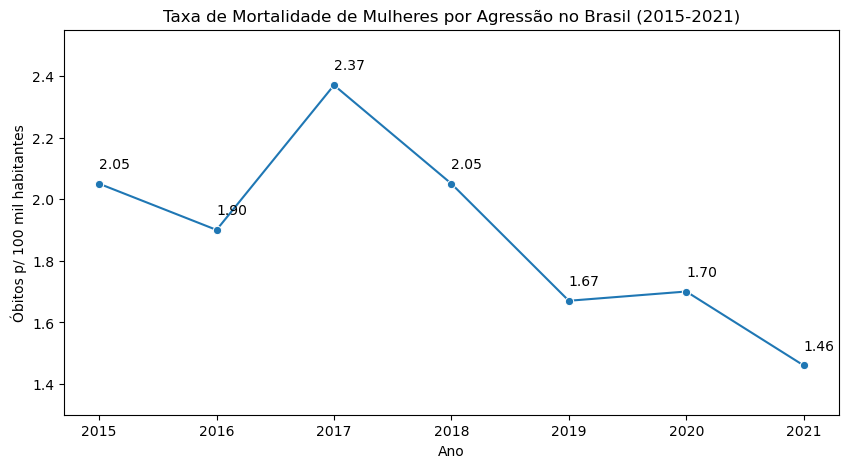

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
grafico_linha = sns.lineplot(
    data=evolucao_brasil, 
    x="ANO",
    y="TAXA_BRASIL",
    marker = "o",
    ax=ax,
)

grafico_linha.set(
    title="Taxa de Mortalidade de Mulheres por Agressão no Brasil (2015-2021)",
    xlabel="Ano", 
    ylabel="Óbitos p/ 100 mil habitantes",
    ylim=(1.30, 2.55)
)

for indice, linha in evolucao_brasil.iterrows():

    grafico_linha.text(
        x=linha["ANO"],
        y=linha["TAXA_BRASIL"]
        + 0.05,
        s=f'{linha["TAXA_BRASIL"]:.2f}',
    )
    
plt.show()

In [19]:
fig.savefig(
    "taxa_mortalidade_brasil.png",
    dpi=300,
    bbox_inches="tight",
)

In [20]:
print(violencia_feminina.columns)

Index(['CONTADOR', 'ORIGEM', 'TIPOBITO', 'DTOBITO', 'HORAOBITO', 'NATURAL',
       'CODMUNNATU', 'DTNASC', 'IDADE', 'SEXO', 'RACACOR', 'ESTCIV', 'ESC',
       'ESC2010', 'SERIESCFAL', 'OCUP', 'CODMUNRES', 'LOCOCOR', 'CODESTAB',
       'ESTABDESCR', 'CODMUNOCOR', 'IDADEMAE', 'ESCMAE', 'ESCMAE2010',
       'SERIESCMAE', 'OCUPMAE', 'QTDFILVIVO', 'QTDFILMORT', 'GRAVIDEZ',
       'SEMAGESTAC', 'GESTACAO', 'PARTO', 'OBITOPARTO', 'PESO', 'TPMORTEOCO',
       'OBITOGRAV', 'OBITOPUERP', 'ASSISTMED', 'EXAME', 'CIRURGIA',
       'NECROPSIA', 'LINHAA', 'LINHAB', 'LINHAC', 'LINHAD', 'LINHAII',
       'CAUSABAS', 'CB_PRE', 'CRM', 'COMUNSVOIM', 'DTATESTADO', 'CIRCOBITO',
       'ACIDTRAB', 'FONTE', 'NUMEROLOTE', 'TPPOS', 'DTINVESTIG', 'CAUSABAS_O',
       'DTCADASTRO', 'ATESTANTE', 'STCODIFICA', 'CODIFICADO', 'VERSAOSIST',
       'VERSAOSCB', 'FONTEINV', 'DTRECEBIM', 'ATESTADO', 'DTRECORIGA',
       'CAUSAMAT', 'ESCMAEAGR1', 'ESCFALAGR1', 'STDOEPIDEM', 'STDONOVA',
       'DIFDATA', 'NUDIASOBCO', 'NUD

In [21]:
ranking_estado_historico = (
    tabela_unificada.groupby("ESTADO")[["OBITOS", "POPULACAO"]]
    .sum()
    .reset_index()
)

ranking_estado_historico["TAXA_ESTADO"] = calcular_taxa_100k(
    ranking_estado_historico["OBITOS"],
    ranking_estado_historico["POPULACAO"]
)

ranking_estado_historico = ranking_estado_historico.sort_values(
    by="TAXA_ESTADO", ascending=False
)

ranking_estado_historico

,ESTADO,OBITOS,POPULACAO,TAXA_ESTADO
21,RR,223,4008753,5.56
0,AC,197,6002365,3.28
13,PA,1832,59398696,3.08
5,CE,1859,63523992,2.93
7,ES,811,28083562,2.89
4,BA,3021,105425946,2.87
8,GO,1385,48344952,2.86
2,AM,809,28706534,2.82
19,RN,686,24505107,2.80
1,AL,622,23452789,2.65


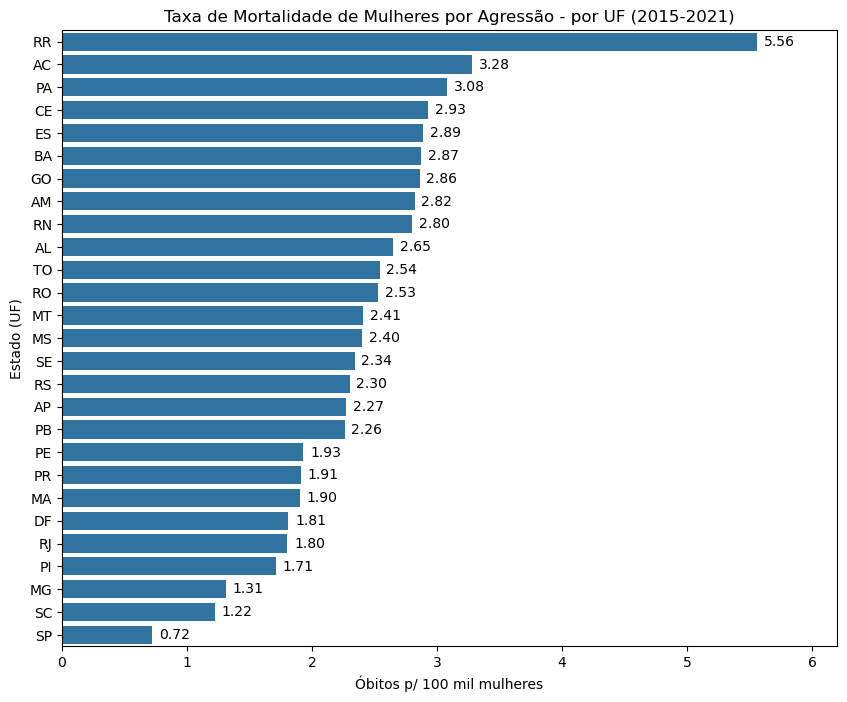

In [27]:
fig, ax = plt.subplots(figsize=(10,8))

grafico_barras = sns.barplot(
    data=ranking_estado_historico,
    x="TAXA_ESTADO",
    y="ESTADO",
    ax=ax
)

grafico_barras.set(
    title="Taxa de Mortalidade de Mulheres por Agressão - por UF (2015-2021)",
    xlabel="Óbitos p/ 100 mil mulheres",
    ylabel="Estado (UF)",
    xlim=(0, 6.2)
)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=5
)
plt.show()